In [12]:
import sys
import warnings

sys.path.append("/kaggle/input/myscripts")
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import transform_to_sequence
from seq_models import SeqDataset, collate_fn, LSTMClassifier, TransformerClassifier, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Income](https://www.openml.org/search?type=data&status=active&id=1590)

In [13]:
dataset_id = 1590
train_data, valid_data, test_data, train_labels, valid_labels, test_labels, _, _ = get_openml_data(dataset_id, transform_func=transform_to_sequence)

In [14]:
train_dataset = SeqDataset(train_data, train_labels)
test_dataset  = SeqDataset(test_data, test_labels)
valid_dataset = SeqDataset(valid_data, valid_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


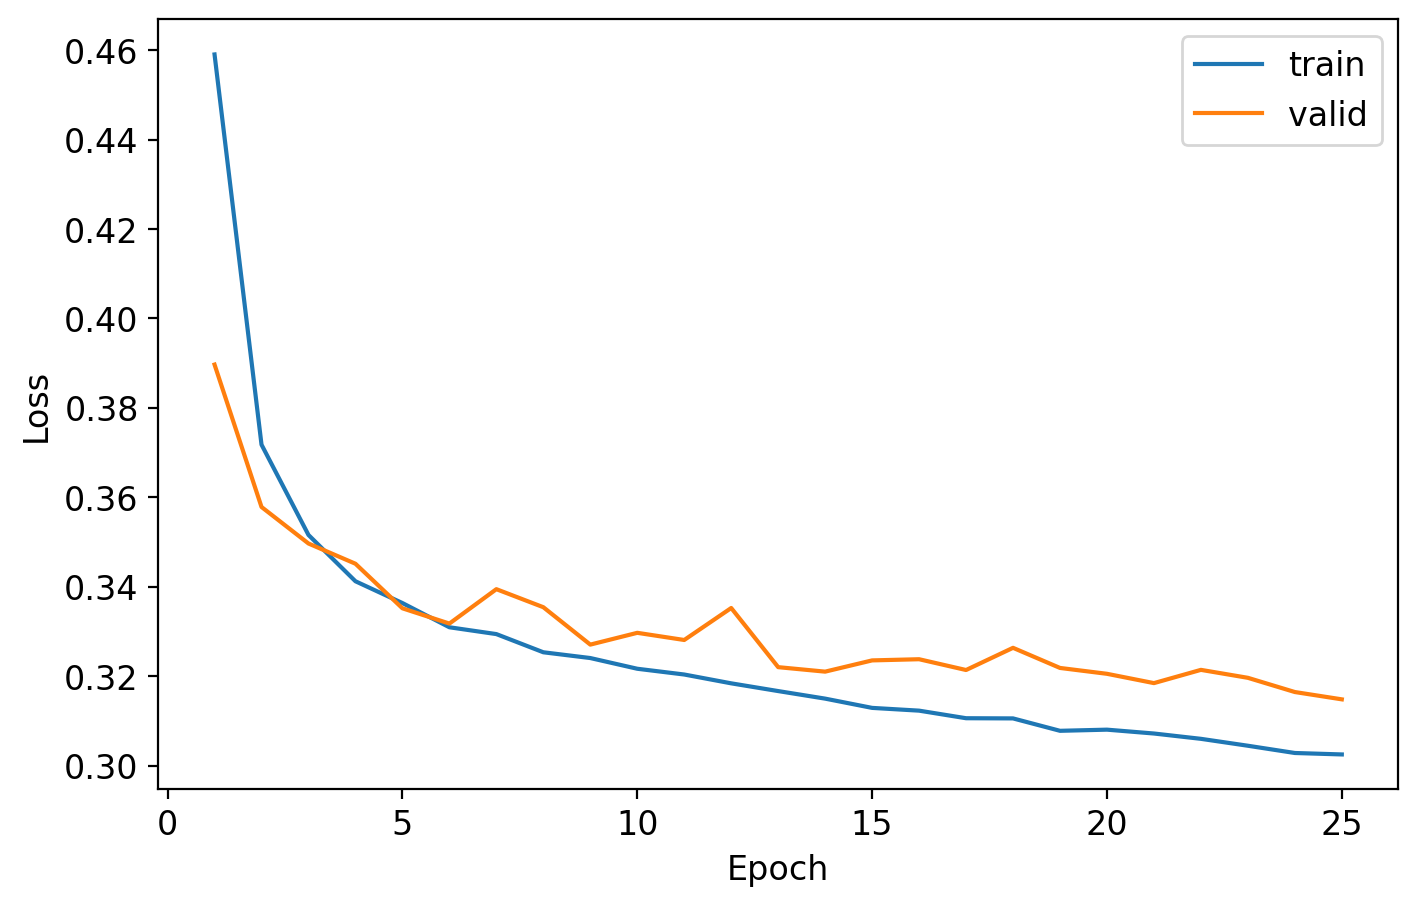

Epoch 25: train loss = 0.3025; valid loss = 0.3148


In [16]:
model_lstm = LSTMClassifier().to(device)
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_lstm, optimizer, 25, train_loader, valid_loader, criterion, device, scheduler=None)

In [17]:
y_true, y_prob, y_pred = evaluate(model_lstm, test_loader, device)
metrics_lstm = bootstrap_metrics(y_true, y_pred, y_prob)

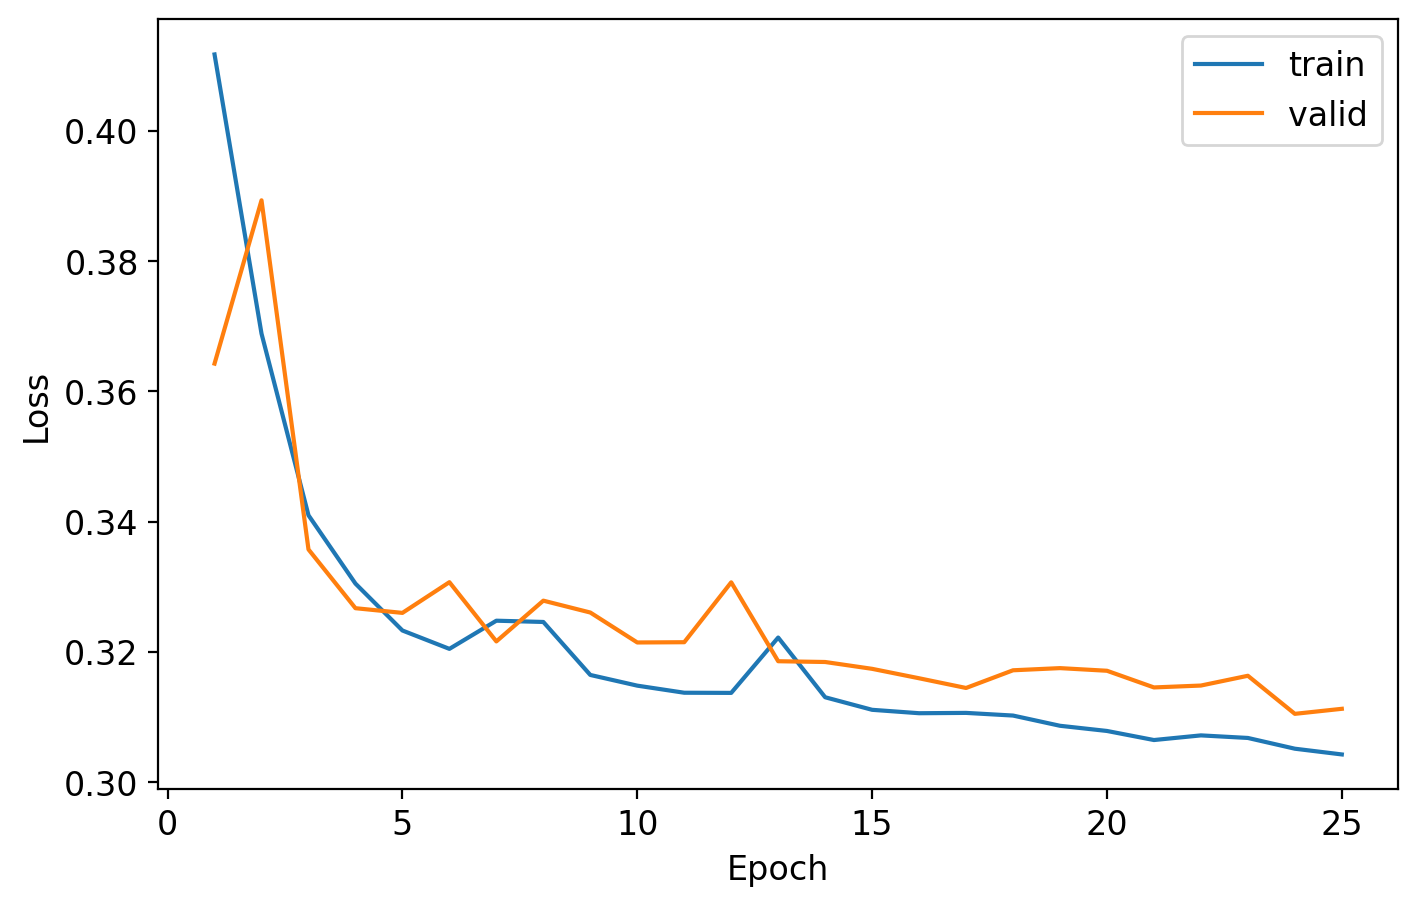

Epoch 25: train loss = 0.3043; valid loss = 0.3113


In [27]:
model_enc = TransformerClassifier(maxlen=len(train_data[0])).to(device)
optimizer = optim.Adam(model_enc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model_enc, optimizer, 25, train_loader, valid_loader, criterion, device, scheduler=None)

In [28]:
y_true, y_prob, y_pred = evaluate(model_enc, test_loader, device)
metrics_enc = bootstrap_metrics(y_true, y_pred, y_prob)

In [29]:
res = pd.DataFrame([{"model": "LSTM"} | metrics_lstm, {"model": "Transformer"} | metrics_enc])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,LSTM,0.9104±0.0045,0.6699±0.0119,0.8606±0.0051,0.7734±0.0139,0.5909±0.0145
1,Transformer,0.9157±0.0043,0.6819±0.0119,0.8635±0.0051,0.7711±0.0139,0.6113±0.0146
